In [36]:
import torch
from torchvision import datasets, transforms

In [37]:
from tensorflow.keras import models, layers
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping
import cv2
import matplotlib.pyplot as plt

In [38]:
Batch_size = 64

data_dir = "C:/Users/J4qk/Desktop/work/DataScience/IntelligentSystems/Classification/FruitClassifier/dataset/train/train/"

dataset = datasets.ImageFolder(data_dir)

In [39]:
dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [40]:
data_train, data_test = torch.utils.data.random_split(dataset,[0.8, 0.2])

Building a model

In [41]:
img, label = data_train[5000]

Compiling model

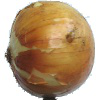

In [42]:
img

In [43]:
len(dataset), len(data_train), len(data_test)

(16854, 13484, 3370)

In [44]:
train_transform = transforms.Compose(
    [transforms.Resize([64, 64]),
     transforms.RandomRotation(180),
     transforms.RandomHorizontalFlip(p=0.5),
     transforms.RandomVerticalFlip(p=0.5),
     transforms.ToTensor()
    ]
)

test_transform = transforms.Compose(
    [transforms.Resize([64, 64]),
     transforms.ToTensor()
    ]
)

In [45]:
train_transform(img).shape

torch.Size([3, 64, 64])

In [46]:
from torch.utils.data import Dataset, DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        img_new = self.transformer(img)

        return img_new, label

In [47]:
train_data = TransformDataset(data_train, train_transform)
test_data = TransformDataset(data_test, test_transform)

In [48]:
train_loader = DataLoader(train_data, batch_size=256)
test_loader = DataLoader(test_data, batch_size=256)

In [49]:
for img, idx in test_loader:
    print(img.shape)
    print(idx.shape)

torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([42, 3, 64, 64])
torch.Size([42])


(64, 64, 3)


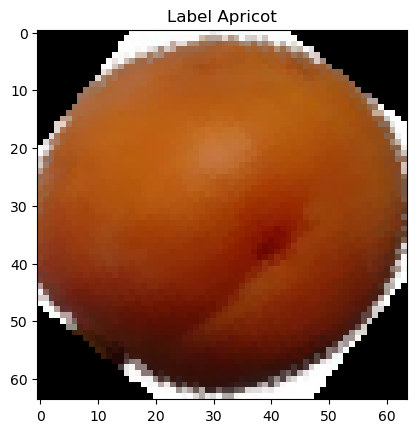

(64, 64, 3)


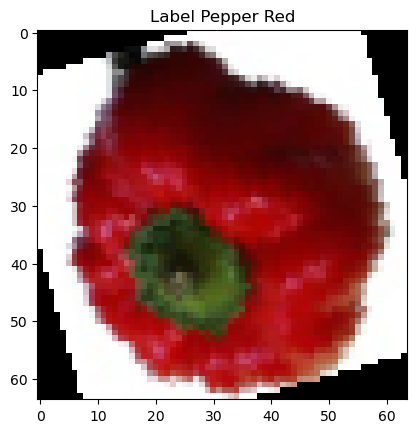

(64, 64, 3)


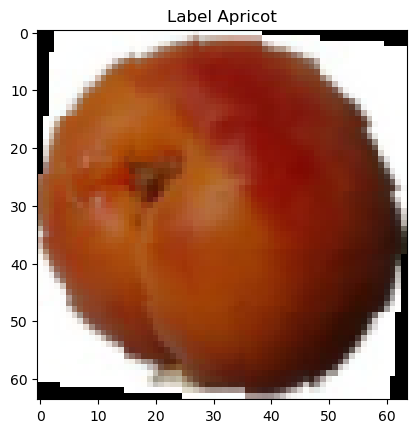

In [50]:
import matplotlib.pyplot as plt

for i in range(3):
    # Converting images to numpy arrays
    img, y = train_data[i]
    img = img.numpy()

    # Transposing to make it look like (height, width, channels)
    img = img.transpose((1, 2, 0))
    print(img.shape)

    # Getting the name of the image
    label = dataset.classes[y]

    # showing the image
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

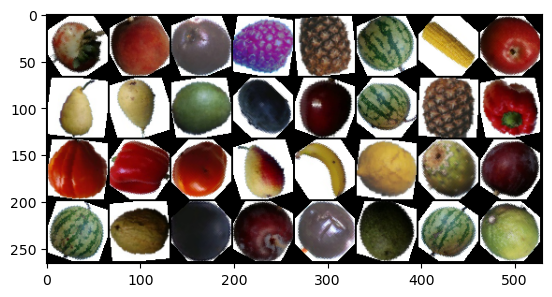

In [51]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0)

plt.imshow(grid)

In [52]:
img, label = train_data[0]

img.shape

torch.Size([3, 64, 64])

In [53]:
len(dataset.classes)

33

In [54]:
from torch import nn

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(12288, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 33)
)

device = 'cpu'
model = model.to(device)

In [55]:
img = img.unsqueeze(0).to(device)
result = model(img)
result

tensor([[ 0.1289,  0.0133,  0.0191, -0.1222,  0.0507, -0.1242,  0.1276, -0.0028,
          0.1449,  0.0485, -0.0867, -0.0510,  0.0369,  0.0870, -0.0565,  0.0612,
         -0.0358,  0.1075, -0.0391,  0.0434,  0.1344, -0.1248,  0.0477,  0.0741,
         -0.0549, -0.0018,  0.0710, -0.1335, -0.0556,  0.1249, -0.0658, -0.0070,
          0.0699]], grad_fn=<AddmmBackward0>)

In [56]:
probs = nn.Softmax(dim=1)(result)
probs

predicted_class = probs.argmax(1).item()
confidence = probs.max().item() * 100

print(f"Prediction: {dataset.classes[predicted_class]}")
print(f"Confidence: {confidence:.2f}%")

print(f"\n Correct data: {dataset.classes[label]}")

if predicted_class == label:
    print("Correct")
else:
    print("Incorrect")

Prediction: Cherry
Confidence: 3.45%

 Correct data: Apricot
Incorrect


In [59]:
loss_fn = nn.CrossEntropyLoss()

# Оптимізатор (Adam) для оновлення ваг моделі
optimizer = torch.optim.Adam(
    model.parameters(),   # параметри нефромережі
    lr=0.001
)

loss_list = []
loss_test_list = []
accuracy_train_list = []
accuracy_test_list = []   

for epoch in range(10):
    
    # ТРЕНУВАННЯ
    model.train()  
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        
        # НОВЕ: розрахунок точності
        correct = (result.argmax(1) == labels).sum().item()
        accuracy = correct / len(labels)
        accuracy_train_list.append(accuracy)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        loss_list.append(loss.cpu().item())
    
    # ВАЛІДАЦІЯ (ЗМІНЕНО)
    model.eval()
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            
            result = model(imgs)
            loss = loss_fn(result, labels)
            
            correct = (result.argmax(1) == labels).sum().item()
            accuracy = correct / len(labels)
            accuracy_test_list.append(accuracy)
            
            loss_test_list.append(loss.cpu().item())
    
    # НОВЕ: вивід статистики
    print(f"\nЕпоха {epoch+1}/10:")
    print(f"Train Accuracy: {sum(accuracy_train_list[-len(train_loader):])/len(train_loader):.2%}")
    print(f"Test Accuracy: {sum(accuracy_test_list[-len(test_loader):])/len(test_loader):.2%}")

# НОВЕ: збереження моделі
torch.save(model.state_dict(), 'fruit_model.pth')


Епоха 1/10:
Train Accuracy: 45.57%
Test Accuracy: 49.14%

Епоха 2/10:
Train Accuracy: 72.86%
Test Accuracy: 74.77%

Епоха 3/10:
Train Accuracy: 81.20%
Test Accuracy: 83.68%

Епоха 4/10:
Train Accuracy: 86.10%
Test Accuracy: 86.93%

Епоха 5/10:
Train Accuracy: 88.63%
Test Accuracy: 91.42%

Епоха 6/10:
Train Accuracy: 90.43%
Test Accuracy: 91.81%

Епоха 7/10:
Train Accuracy: 91.45%
Test Accuracy: 92.99%

Епоха 8/10:
Train Accuracy: 92.30%
Test Accuracy: 93.63%

Епоха 9/10:
Train Accuracy: 93.27%
Test Accuracy: 95.59%

Епоха 10/10:
Train Accuracy: 93.84%
Test Accuracy: 95.06%


In [60]:
correct_predictions = 0
total_predictions = 0

for imgs, labels in test_loader:
    imgs = imgs.to(device)
    predictions = model(imgs).argmax(1)
    
    correct_predictions += (predictions == labels.to(device)).sum().item()
    total_predictions += len(labels)

accuracy = correct_predictions / total_predictions * 100
print(f"Точність моделі: {accuracy:.2f}%")

Точність моделі: 95.04%


In [61]:
import torch

model.load_state_dict(torch.load("fruit_model.pth", map_location="cpu"))
model.eval()

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=12288, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=33, bias=True)
)

In [63]:
from PIL import Image
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

img = Image.open("pear.jpg").convert("RGB")
img = transform(img).unsqueeze(0)  # (1, 3, 224, 224)

with torch.no_grad():
    output = model(img)
    pred = torch.argmax(output, dim=1)

idx_to_class = {v:k for k,v in train_data.dataset.dataset.class_to_idx.items()}

pred = torch.argmax(output, dim=1).item()

print(idx_to_class[pred])

Corn


In [64]:
import joblib

joblib.dump(model, "fruitModel.pkl")

['fruitModel.pkl']